# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 96)
        self.enc4 = conv_block(96, 128)
        # Bottleneck 부분
        self.center = conv_block(128, 128)
        self.pool = nn.MaxPool2d(kernel_size=2)

        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, kernel_size=1)
                )

        # 디코더 부분 목표 
        self.up4 = upsample_layer(128, 96)
        self.dec4 = conv_block(96 + 128, 96)
        self.up3 = upsample_layer(96, 64)
        self.dec3 = conv_block(64 + 96, 64)
        self.up2 = upsample_layer(64, 32)
        self.dec2 = conv_block(32 + 64, 32)
        self.up1 = upsample_layer(32, 16)
        self.dec1 = conv_block(16 + 32, 16)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더 
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
        # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [6]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.405542..4.3847814].


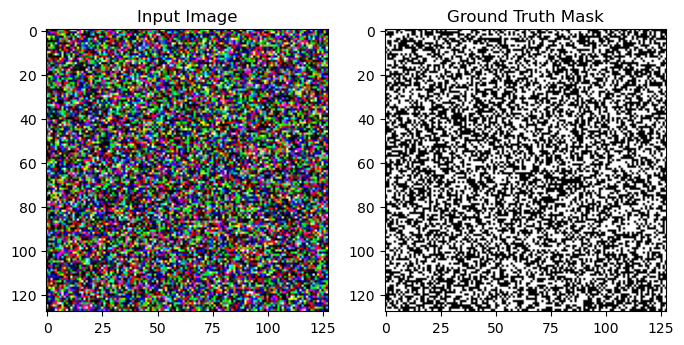

In [7]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [8]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6932
Epoch 2, Loss: 0.6931
Epoch 3, Loss: 0.6931
Epoch 4, Loss: 0.6930
Epoch 5, Loss: 0.6929
Epoch 6, Loss: 0.6927
Epoch 7, Loss: 0.6925
Epoch 8, Loss: 0.6922
Epoch 9, Loss: 0.6917
Epoch 10, Loss: 0.6912


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---

U-Net은 CNN 기반 모델로 생의학 이미지 분할을 위해 고안됨
인코더-디코더 구조를 갖고, 인코더는 컨볼루션과 풀링으로 특징을 추출하고, 디코더는 업샘플링으로 해상도를 복원.
각 디코더 단계에서는 각각에 대응되는 인코더 출력을 skip connection으로 이어 붙여서 적은 수의 학습 데이터로도 높은 정확도의 분할을 수행함. 이미 검증이 끝난 패치는 건너뛰어 빠른 속도로 학습하고, 트레이드 오프에 빠지지 않는다는 장점이 있다. 

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

- [DeepLab v1]: VGG-16 기반 백본에 Atrous (dilated) convolution을 도입하여 해상도 손실 없이 넓은 수용영역을 확보했다. 마지막 몇 개 층의 stride를 제거하고 dilation으로 보완한다. Fully connected CRF(Conditional Random Field)를 후처리로 사용한다. 

- [DeepLab v2]: V1의 구조에 ASPP (Atrous Spatial Pyramid Pooling) 모듈을 추가하여 다양한 스케일의 정보를 병렬적으로 추출한다. CRF를 후처리로 사용한다. 

- [DeepLab v3]: ResNet 또는 Xception 백본을 사용하고, ASPP를 개선하여 성능을 향상시켰다. 이미지 풀링(global average pooling)을 ASPP에 추가해 더 넓은 컨텍스트를 포착한다. CRF 없이도 성능이 높아, 후처리 업이도 높은 성능을 보인다. 

- [DeepLab v3+]: 완전연결층의 단점을 보완하기 위해 Atrous 합성곱을 사용하는 네트워크로 일반적으로 인코더-디코더 구조에서는 불가능했던, 인코더에서 추출된 특성 맵의 해상도를 Atrous 합성곱을 도입하여 제어 가능하게 한다. V3에 디코더 구조를 추가하여 공간적 세부 정보를 복원한다. 